In [79]:
# necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [80]:
# load data
df = pd.read_excel(
    "../data/Bisoprolol_icsr_sample_1068rows.xlsx",
    engine="openpyxl"
)
print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (1068, 67)


In [140]:
# cases
cases = df.drop_duplicates(
    subset="safetyreportid"
).copy()

print("Reaction records:", len(df))
print("Unique cases:", cases["safetyreportid"].nunique())

Reaction records: 1068
Unique cases: 1024


In [141]:
# date check
df["receivedate"] = pd.to_datetime(
    df["receivedate"],
    format="%Y%m%d",
    errors="coerce"
)

cases["receivedate"] = pd.to_datetime(
    cases["receivedate"],
    format="%Y%m%d",
    errors="coerce"
)

print("Reporting period:")
print("Start:", cases["receivedate"].min())
print("End:", cases["receivedate"].max())

print(
    "Invalid receivedate values:",
    cases["receivedate"].isna().sum()
)

Reporting period:
Start: 2024-12-27 00:00:00
End: 2025-12-26 00:00:00
Invalid receivedate values: 0


In [142]:
# total cases
total_cases = cases["safetyreportid"].nunique()

print("Total cases:", total_cases)

Total cases: 1024


In [143]:
# serious cases
serious_cases = cases[
    cases["serious"] == "serious"
].copy()

non_serious_cases = cases[
    cases["serious"] == "not serious"
].copy()

serious_count = len(serious_cases)
non_serious_count = len(non_serious_cases)

print("Serious cases:", serious_count)
print("Non-serious cases:", non_serious_count)

Serious cases: 1023
Non-serious cases: 1


In [144]:
serious_percentage = round(
    serious_count / total_cases * 100,
    2
)

non_serious_percentage = round(
    non_serious_count / total_cases * 100,
    2
)

print(f"Serious: {serious_percentage}%")
print(f"Non-serious: {non_serious_percentage}%")

Serious: 99.9%
Non-serious: 0.1%


In [145]:
seriousness_cols = [
    "seriousnessdeath",
    "seriousnesslifethreatening",
    "seriousnesshospitalization",
    "seriousnessdisabling",
    "seriousnesscongenitalanomali",
    "seriousnessother"
]

for col in seriousness_cols:
    print(f"\n--- {col} ---")
    print(
        cases[col].value_counts(
            dropna=False
        )
    )


--- seriousnessdeath ---
seriousnessdeath
no     957
yes     67
Name: count, dtype: int64

--- seriousnesslifethreatening ---
seriousnesslifethreatening
no     919
yes    105
Name: count, dtype: int64

--- seriousnesshospitalization ---
seriousnesshospitalization
no     544
yes    480
Name: count, dtype: int64

--- seriousnessdisabling ---
seriousnessdisabling
no     981
yes     43
Name: count, dtype: int64

--- seriousnesscongenitalanomali ---
seriousnesscongenitalanomali
no     1017
yes       7
Name: count, dtype: int64

--- seriousnessother ---
seriousnessother
yes    905
no     119
Name: count, dtype: int64


In [146]:
expedited_cases = cases[
    cases["fulfillexpeditecriteria"] == "yes"
].copy()

non_expedited_cases = cases[
    cases["fulfillexpeditecriteria"] == "no"
].copy()

expedited_count = len(expedited_cases)
non_expedited_count = len(non_expedited_cases)

print("Expedited cases:", expedited_count)
print("Non-expedited cases:", non_expedited_count)

Expedited cases: 1023
Non-expedited cases: 1


In [147]:
expedited_percentage = round(
    expedited_count / total_cases * 100,
    2
)

non_expedited_percentage = round(
    non_expedited_count / total_cases * 100,
    2
)

print(f"Expedited: {expedited_percentage}%")
print(f"Non-expedited: {non_expedited_percentage}%")

Expedited: 99.9%
Non-expedited: 0.1%


In [148]:
# age analysis
age_units = (
    cases["patient_patientonsetageunit"]
    .value_counts(dropna=False)
)

print(age_units)

patient_patientonsetageunit
year     938
NaN       74
month      5
day        3
800        3
week       1
Name: count, dtype: int64


In [149]:
def normalize_age_to_years(row):
    age = row["patient_patientonsetage"]
    unit = row["patient_patientonsetageunit"]

    if pd.isna(age) or pd.isna(unit):
        return np.nan

    if unit == "year":
        return float(age)

    elif unit == "month":
        return float(age) / 12

    elif unit == "week":
        return float(age) / 52.1429

    elif unit == "day":
        return float(age) / 365.25

    else:
        # Unknown numeric code such as 800
        return np.nan


cases["age_years"] = cases.apply(
    normalize_age_to_years,
    axis=1
)

In [150]:
def create_age_group(age):
    if pd.isna(age):
        return "Unknown"

    elif age < 18:
        return "<18"

    elif age <= 30:
        return "18-30"

    elif age <= 45:
        return "31-45"

    elif age <= 60:
        return "46-60"

    elif age <= 75:
        return "61-75"

    else:
        return "76+"


cases["age_group"] = cases[
    "age_years"
].apply(create_age_group)

In [151]:
# sex analysis
sex_distribution = (
    cases["patient_patientsex"]
    .value_counts(
        dropna=False
    )
)

sex_percentage = (
    cases["patient_patientsex"]
    .value_counts(
        normalize=True,
        dropna=False
    )
    .mul(100)
    .round(2)
)

print("Sex distribution:")
print(sex_distribution)

print("\nSex percentage:")
print(sex_percentage)

Sex distribution:
patient_patientsex
female    503
male      493
NaN        28
Name: count, dtype: int64

Sex percentage:
patient_patientsex
female    49.12
male      48.14
NaN        2.73
Name: proportion, dtype: float64


In [ ]:
# country analysis
country_distribution = (
    cases["occurcountry"]
    .value_counts(
        dropna=False
    )
)

country_percentage = (
    cases["occurcountry"]
    .value_counts(
        normalize=True,
        dropna=False
    )
    .mul(100)
    .round(2)
)

print("Top countries:")
print(country_distribution.head(20))

print("\nCountry percentage:")
print(country_percentage.head(20))

In [152]:
# reaction analysis
reaction_col = (
    "patient_reaction_reactionmeddrapt"
)

multiple_reactions = (
    df[reaction_col]
    .astype(str)
    .str.contains(",")
)

print(
    "Rows containing multiple reactions:",
    multiple_reactions.sum()
)

Rows containing multiple reactions: 681


In [153]:
def split_reactions(value):
    if pd.isna(value):
        return []

    return [
        x.strip()
        for x in str(value).split(",")
        if x.strip()
    ]

In [154]:
reactions = df[
    [
        "safetyreportid",
        reaction_col
    ]
].copy()

reactions[reaction_col] = (
    reactions[reaction_col]
    .apply(split_reactions)
)

reactions = reactions.explode(
    reaction_col
)

reactions = reactions[
    reactions[reaction_col].notna()
].copy()

print(
    "Normalized reaction records:",
    len(reactions)
)

Normalized reaction records: 3648


In [155]:
reaction_case_counts = (
    reactions
    .groupby(reaction_col)["safetyreportid"]
    .nunique()
    .sort_values(
        ascending=False
    )
)

print("Top 20 reactions:")
print(
    reaction_case_counts.head(20)
)

Top 20 reactions:
patient_reaction_reactionmeddrapt
Acute kidney injury           80
Drug ineffective              54
Hypotension                   46
Drug interaction              43
Dyspnoea                      38
Bradycardia                   37
Dizziness                     36
Fatigue                       33
Off label use                 31
Fall                          30
Diarrhoea                     30
Condition aggravated          27
Hypokalaemia                  27
Medication error              25
Asthenia                      25
Hyponatraemia                 24
Toxicity to various agents    23
Confusional state             23
Arthralgia                    22
Syncope                       20
Name: safetyreportid, dtype: int64


In [160]:
serious_case_ids = set(
    serious_cases["safetyreportid"]
)

serious_reactions = reactions[
    reactions["safetyreportid"].isin(
        serious_case_ids
    )
].copy()

serious_reaction_counts = (
    serious_reactions
    .groupby(reaction_col)["safetyreportid"]
    .nunique()
    .sort_values(ascending=False)
)

print("Top serious reactions:")
print(
    serious_reaction_counts.head(20)
)

Top serious reactions:
patient_reaction_reactionmeddrapt
Acute kidney injury           80
Drug ineffective              53
Hypotension                   46
Drug interaction              43
Dyspnoea                      38
Bradycardia                   37
Dizziness                     36
Fatigue                       33
Off label use                 31
Fall                          30
Diarrhoea                     30
Condition aggravated          27
Hypokalaemia                  27
Medication error              25
Asthenia                      25
Hyponatraemia                 24
Toxicity to various agents    23
Confusional state             23
Arthralgia                    22
Syncope                       20
Name: safetyreportid, dtype: int64


In [162]:
# 15-day alert reactions
expedited_case_ids = set(
    expedited_cases["safetyreportid"]
)

expedited_reactions = reactions[
    reactions["safetyreportid"].isin(
        expedited_case_ids
    )
].copy()

expedited_reaction_counts = (
    expedited_reactions
    .groupby(reaction_col)["safetyreportid"]
    .nunique()
    .sort_values(ascending=False)
)

print("Top expedited reactions:")
print(
    expedited_reaction_counts.head(20)
)

Top expedited reactions:
patient_reaction_reactionmeddrapt
Acute kidney injury           80
Drug ineffective              53
Hypotension                   46
Drug interaction              43
Dyspnoea                      38
Bradycardia                   37
Dizziness                     36
Fatigue                       33
Off label use                 31
Fall                          30
Diarrhoea                     30
Condition aggravated          27
Hypokalaemia                  27
Medication error              25
Asthenia                      25
Hyponatraemia                 24
Toxicity to various agents    23
Confusional state             23
Arthralgia                    22
Syncope                       20
Name: safetyreportid, dtype: int64


In [163]:
# outcome stuff
outcome_col = (
    "patient_reaction_reactionoutcome"
)

print(
    "Unique raw outcomes:",
    df[outcome_col].nunique()
)

print("\nTop raw outcomes:")

print(
    df[outcome_col]
    .value_counts(
        dropna=False
    )
    .head(20)
)

Unique raw outcomes: 251

Top raw outcomes:
patient_reaction_reactionoutcome
recovered/resolved                                                                                                   147
recovering/resolving                                                                                                  82
recovered/resolved,recovered/resolved                                                                                 76
not recovered/not resolved/ongoing                                                                                    67
unknown                                                                                                               66
recovered/resolved,recovered/resolved,recovered/resolved                                                              52
unknown,unknown                                                                                                       35
recovering/resolving,recovering/resolving                                   

In [164]:
multiple_outcomes = (
    df[outcome_col]
    .astype(str)
    .str.contains(",")
)

print(
    "Rows containing multiple outcomes:",
    multiple_outcomes.sum()
)

Rows containing multiple outcomes: 681


In [165]:
def split_outcomes(value):
    if pd.isna(value):
        return []

    return [
        x.strip()
        for x in str(value).split(",")
        if x.strip()
    ]

In [166]:
outcomes = df[
    [
        "safetyreportid",
        outcome_col
    ]
].copy()

outcomes[outcome_col] = (
    outcomes[outcome_col]
    .apply(split_outcomes)
)

outcomes = outcomes.explode(
    outcome_col
)

outcomes = outcomes[
    outcomes[outcome_col].notna()
].copy()

print(
    "Normalized outcome records:",
    len(outcomes)
)

Normalized outcome records: 3642


In [167]:
outcome_case_counts = (
    outcomes
    .groupby(outcome_col)["safetyreportid"]
    .nunique()
    .sort_values(
        ascending=False
    )
)

print("Outcome counts:")
print(outcome_case_counts)

Outcome counts:
patient_reaction_reactionoutcome
recovered/resolved                    494
unknown                               330
recovering/resolving                  227
not recovered/not resolved/ongoing    195
fatal                                  68
recovered/resolved with sequelae       21
Name: safetyreportid, dtype: int64


In [168]:
outcome_percentage = (
    outcome_case_counts
    .div(total_cases)
    .mul(100)
    .round(2)
)

print("Outcome percentages:")
print(outcome_percentage)

Outcome percentages:
patient_reaction_reactionoutcome
recovered/resolved                    48.24
unknown                               32.23
recovering/resolving                  22.17
not recovered/not resolved/ongoing    19.04
fatal                                  6.64
recovered/resolved with sequelae       2.05
Name: safetyreportid, dtype: float64


In [169]:
fatal_outcomes = outcomes[
    outcomes[outcome_col] == "fatal"
].copy()

fatal_case_ids = set(
    fatal_outcomes["safetyreportid"]
)

print(
    "Fatal cases:",
    len(fatal_case_ids)
)

Fatal cases: 68


In [170]:
# fatal case reactions
fatal_reactions = reactions[
    reactions["safetyreportid"].isin(
        fatal_case_ids
    )
].copy()

fatal_reaction_counts = (
    fatal_reactions
    .groupby(reaction_col)["safetyreportid"]
    .nunique()
    .sort_values(
        ascending=False
    )
)

print(
    "Top reactions among fatal cases:"
)

print(
    fatal_reaction_counts.head(20)
)

Top reactions among fatal cases:
patient_reaction_reactionmeddrapt
Acute kidney injury                 7
Death                               6
Respiratory failure                 6
Fall                                5
Pneumonitis                         4
Septic shock                        4
Febrile bone marrow aplasia         3
Dyspnoea                            3
Pneumonia                           3
Pancytopenia                        3
Stevens-Johnson syndrome            3
Sepsis                              3
Lactic acidosis                     3
Toxic epidermal necrolysis          3
Thrombocytopenia                    3
Asthenia                            3
Encephalopathy                      2
Wrong patient                       2
Hypotension                         2
Pneumocystis jirovecii pneumonia    2
Name: safetyreportid, dtype: int64


In [171]:
# monthly cases
cases["report_month"] = (
    cases["receivedate"]
    .dt.to_period("M")
)

monthly_cases = (
    cases
    .groupby("report_month")
    .size()
)

print("Monthly cases:")
print(monthly_cases)

Monthly cases:
report_month
2024-12     21
2025-01     75
2025-02     94
2025-03     83
2025-04     78
2025-05     80
2025-06     84
2025-07    109
2025-08     64
2025-09     76
2025-10    102
2025-11     75
2025-12     83
Freq: M, dtype: int64


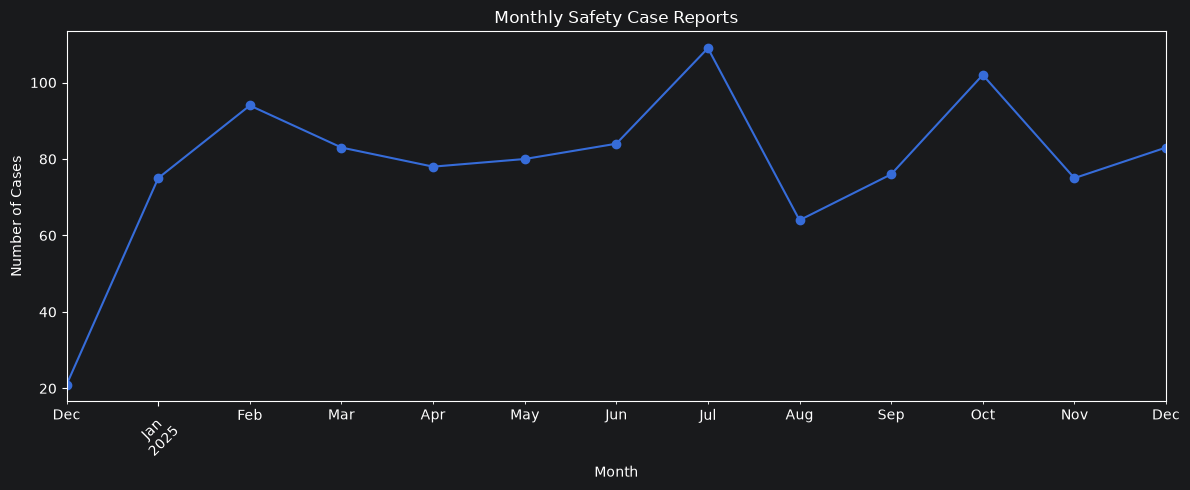

In [172]:
plt.figure(figsize=(12, 5))

monthly_cases.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Monthly Safety Case Reports"
)

plt.xlabel("Month")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [173]:
monthly_serious = (
    serious_cases
    .groupby(
        serious_cases["receivedate"]
        .dt.to_period("M")
    )
    .size()
)

print("Monthly serious cases:")
print(monthly_serious)

Monthly serious cases:
receivedate
2024-12     21
2025-01     75
2025-02     94
2025-03     83
2025-04     78
2025-05     80
2025-06     84
2025-07    108
2025-08     64
2025-09     76
2025-10    102
2025-11     75
2025-12     83
Freq: M, dtype: int64


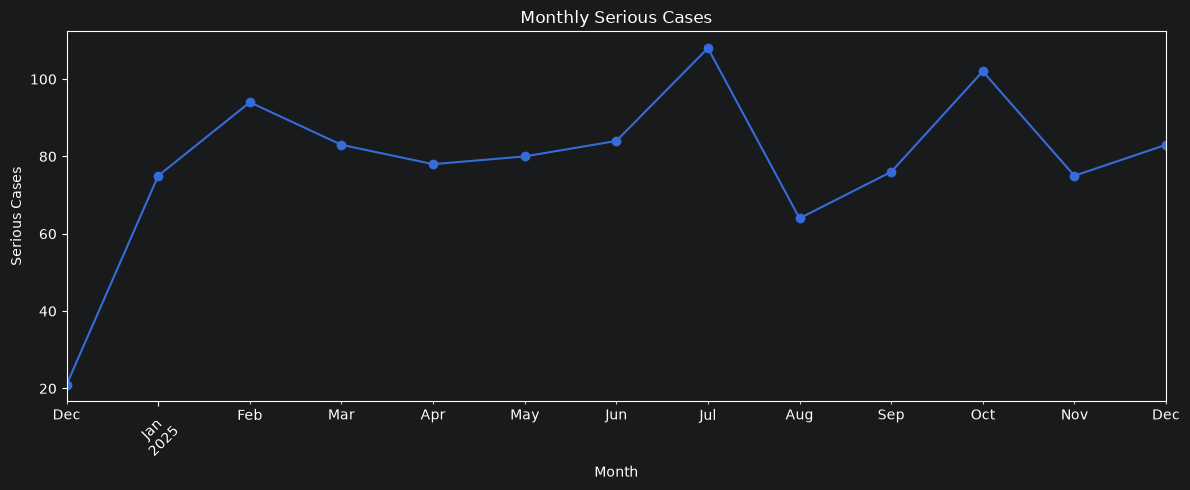

In [174]:
plt.figure(figsize=(12, 5))

monthly_serious.plot(
    kind="line",
    marker="o"
)

plt.title(
    "Monthly Serious Cases"
)

plt.xlabel("Month")
plt.ylabel("Serious Cases")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [175]:
# seriousness criteria
for col in seriousness_cols:
    print(f"\n--- {col} ---")

    print(
        cases[col]
        .value_counts(
            dropna=False
        )
    )


--- seriousnessdeath ---
seriousnessdeath
no     957
yes     67
Name: count, dtype: int64

--- seriousnesslifethreatening ---
seriousnesslifethreatening
no     919
yes    105
Name: count, dtype: int64

--- seriousnesshospitalization ---
seriousnesshospitalization
no     544
yes    480
Name: count, dtype: int64

--- seriousnessdisabling ---
seriousnessdisabling
no     981
yes     43
Name: count, dtype: int64

--- seriousnesscongenitalanomali ---
seriousnesscongenitalanomali
no     1017
yes       7
Name: count, dtype: int64

--- seriousnessother ---
seriousnessother
yes    905
no     119
Name: count, dtype: int64


In [176]:
seriousness_summary = {}

for col in seriousness_cols:

    count = (
        cases[col]
        .astype(str)
        .str.lower()
        .eq("yes")
        .sum()
    )

    seriousness_summary[col] = int(count)

print(
    seriousness_summary
)

{'seriousnessdeath': 67, 'seriousnesslifethreatening': 105, 'seriousnesshospitalization': 480, 'seriousnessdisabling': 43, 'seriousnesscongenitalanomali': 7, 'seriousnessother': 905}


In [177]:
analysis_results = {

    "dataset": {
        "reaction_records": int(len(df)),
        "unique_cases": int(total_cases)
    },

    "reporting_period": {
        "start": str(
            cases["receivedate"]
            .min()
            .date()
        ),
        "end": str(
            cases["receivedate"]
            .max()
            .date()
        )
    },

    "seriousness": {
        "serious_cases": int(
            serious_count
        ),
        "non_serious_cases": int(
            non_serious_count
        ),
        "serious_percentage": float(
            serious_percentage
        ),
        "non_serious_percentage": float(
            non_serious_percentage
        )
    },

    "expedited": {
        "expedited_cases": int(
            expedited_count
        ),
        "non_expedited_cases": int(
            non_expedited_count
        ),
        "expedited_percentage": float(
            expedited_percentage
        ),
        "non_expedited_percentage": float(
            non_expedited_percentage
        )
    },

    "seriousness_criteria": (
        seriousness_summary
    ),

    "age_distribution": (
        age_distribution.to_dict()
    ),

    "age_percentage": (
        age_percentage.to_dict()
    ),

    "sex_distribution": (
        sex_distribution.to_dict()
    ),

    "sex_percentage": (
        sex_percentage.to_dict()
    ),

    "country_distribution": (
        country_distribution
        .head(20)
        .to_dict()
    ),

    "country_percentage": (
        country_percentage
        .head(20)
        .to_dict()
    ),

    "top_reactions": (
        reaction_case_counts
        .head(20)
        .to_dict()
    ),

    "top_serious_reactions": (
        serious_reaction_counts
        .head(20)
        .to_dict()
    ),

    "top_expedited_reactions": (
        expedited_reaction_counts
        .head(20)
        .to_dict()
    ),

    "top_fatal_case_reactions": (
        fatal_reaction_counts
        .head(20)
        .to_dict()
    ),

    "outcomes": (
        outcome_case_counts.to_dict()
    ),

    "outcome_percentage": (
        outcome_percentage.to_dict()
    ),

    "fatal_cases": int(
        len(fatal_case_ids)
    ),

    "monthly_cases": {
        str(month): int(count)
        for month, count
        in monthly_cases.items()
    },

    "monthly_serious_cases": {
        str(month): int(count)
        for month, count
        in monthly_serious.items()
    }
}

In [178]:
OUTPUT_DIR = "../output"

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

OUTPUT_FILE = os.path.join(
    OUTPUT_DIR,
    "analysis_results.json"
)

with open(
    OUTPUT_FILE,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        analysis_results,
        f,
        indent=4,
        ensure_ascii=False
    )

print(
    "Analysis results saved to:",
    OUTPUT_FILE
)

Analysis results saved to: ../output\analysis_results.json


In [179]:
# check output
print(
    json.dumps(
        analysis_results,
        indent=4,
        ensure_ascii=False
    )
)

{
    "dataset": {
        "reaction_records": 1068,
        "unique_cases": 1024
    },
    "reporting_period": {
        "start": "2024-12-27",
        "end": "2025-12-26"
    },
    "seriousness": {
        "serious_cases": 1023,
        "non_serious_cases": 1,
        "serious_percentage": 99.9,
        "non_serious_percentage": 0.1
    },
    "expedited": {
        "expedited_cases": 1023,
        "non_expedited_cases": 1,
        "expedited_percentage": 99.9,
        "non_expedited_percentage": 0.1
    },
    "seriousness_criteria": {
        "seriousnessdeath": 67,
        "seriousnesslifethreatening": 105,
        "seriousnesshospitalization": 480,
        "seriousnessdisabling": 43,
        "seriousnesscongenitalanomali": 7,
        "seriousnessother": 905
    },
    "age_distribution": {
        "76+": 379,
        "61-75": 362,
        "46-60": 134,
        "Unknown": 87,
        "31-45": 36,
        "<18": 16,
        "18-30": 10
    },
    "age_percentage": {
        "76+"